In [1]:
!pip install timm -q
print("✅ Cài đặt xong! Môi trường hoàn toàn sạch sẽ.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
import os, random, time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.metrics import roc_curve, auc, accuracy_score
from scipy.optimize import brentq
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE} | NumPy: {np.__version__} | Torch: {torch.__version__}")

Device: cuda | NumPy: 2.4.6 | Torch: 2.10.0+cu128


In [3]:
BASE = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23'

FAKE_DIRS = {
    'Deepfakes':      os.path.join(BASE, 'Deepfakes'),
    'Face2Face':      os.path.join(BASE, 'Face2Face'),
    'FaceSwap':       os.path.join(BASE, 'FaceSwap'),
    'NeuralTextures': os.path.join(BASE, 'NeuralTextures'),
}
REAL_DIR   = os.path.join(BASE, 'original')

In [4]:
OUT_DIR = '/kaggle/working/frames'
os.makedirs(OUT_DIR, exist_ok=True)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Giới hạn số video mỗi loại để tránh tốn quá nhiều thời gian cắt (có thể tăng lên nếu muốn)
MAX_VIDEOS_PER_CLASS = 200
FRAMES_PER_VIDEO = 4

def extract_faces_opencv(video_list, save_path):
    os.makedirs(save_path, exist_ok=True)
    count = 0
    for vid_path in tqdm(video_list, desc=f"Đang cắt -> {save_path.split('/')[-1]}"):
        cap = cv2.VideoCapture(vid_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0: 
            cap.release()
            continue
            
        target_frames = set([int(i * total_frames / FRAMES_PER_VIDEO) for i in range(FRAMES_PER_VIDEO)])
        vid_name = os.path.basename(vid_path).split('.')[0]
        
        current_frame = 0; saved = 0
        
        while True:
            ret = cap.grab()
            if not ret: break
            if current_frame in target_frames:
                ret, frame = cap.retrieve()
                if ret:
                    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
                    
                    if len(faces) > 0:
                        faces = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)
                        x, y, w, h = faces[0]
                        ih, iw = frame.shape[:2]
                        pad_x, pad_y = int(w * 0.1), int(h * 0.15)
                        x1, y1 = max(0, x - pad_x), max(0, y - pad_y * 2) 
                        x2, y2 = min(iw, x + w + pad_x), min(ih, y + h + pad_y)
                        
                        face_crop = frame[y1:y2, x1:x2]
                        if face_crop.size > 0:
                            cv2.imwrite(os.path.join(save_path, f"{vid_name}_{saved}.jpg"), face_crop)
                            count += 1
                saved += 1
                if saved >= FRAMES_PER_VIDEO: break 
            current_frame += 1
        cap.release()
    return count

print("=== BẮT ĐẦU CẮT ẢNH TỪ VIDEO BẰNG OPENCV ===")
# 1. Cắt ảnh REAL
real_vids = [os.path.join(REAL_DIR, f) for f in os.listdir(REAL_DIR) if f.endswith('.mp4')]
random.shuffle(real_vids)
extract_faces_opencv(real_vids[:MAX_VIDEOS_PER_CLASS], os.path.join(OUT_DIR, 'original'))

# 2. Cắt ảnh FAKE cho từng loại
for name, fdir in FAKE_DIRS.items():
    if os.path.exists(fdir):
        vids = [os.path.join(fdir, f) for f in os.listdir(fdir) if f.endswith('.mp4')]
        random.shuffle(vids)
        extract_faces_opencv(vids[:MAX_VIDEOS_PER_CLASS], os.path.join(OUT_DIR, name))

print("✅ Đã hoàn thành quá trình cắt ảnh khuôn mặt!")

=== BẮT ĐẦU CẮT ẢNH TỪ VIDEO BẰNG OPENCV ===


Đang cắt -> original:   0%|          | 0/200 [00:00<?, ?it/s]

Đang cắt -> Deepfakes:   0%|          | 0/200 [00:00<?, ?it/s]

Đang cắt -> Face2Face:   0%|          | 0/200 [00:00<?, ?it/s]

Đang cắt -> FaceSwap:   0%|          | 0/200 [00:00<?, ?it/s]

Đang cắt -> NeuralTextures:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Đã hoàn thành quá trình cắt ảnh khuôn mặt!


In [5]:
MANIP2IDX = {'Deepfakes': 0, 'Face2Face': 1, 'FaceSwap': 2, 'NeuralTextures': 3}

def collect_images(folder, label_binary, label_manip):
    paths = []
    if os.path.exists(folder):
        for f in os.listdir(folder):
            if f.lower().endswith('.jpg'):
                paths.append((os.path.join(folder, f), label_binary, label_manip))
    return paths

all_samples = []
all_samples += collect_images(os.path.join(OUT_DIR, 'original'), 0, 4)
for name in FAKE_DIRS.keys():
    all_samples += collect_images(os.path.join(OUT_DIR, name), 1, MANIP2IDX[name])

random.shuffle(all_samples)
n = len(all_samples)
assert n > 0, "❌ Không tìm thấy ảnh nào! Quá trình cắt video bị lỗi."

n_train = int(0.8 * n); n_val = int(0.1 * n)
train_s = all_samples[:n_train]
val_s   = all_samples[n_train:n_train+n_val]
test_s  = all_samples[n_train+n_val:]
print(f"✅ Tổng số ảnh đã cắt: {n}")
print(f"✅ Chia tập: Train: {len(train_s)} | Val: {len(val_s)} | Test: {len(test_s)}")

✅ Tổng số ảnh đã cắt: 3983
✅ Chia tập: Train: 3186 | Val: 398 | Test: 399


In [6]:
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-4

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2, 0.2, 0.2, 0.05),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class FFDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, lb, lm = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), lb, lm

train_loader = DataLoader(FFDataset(train_s, train_tf), BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(FFDataset(val_s,   val_tf),   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(FFDataset(test_s,  val_tf),   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("✅ DataLoader sẵn sàng")

✅ DataLoader sẵn sàng


In [7]:
class XceptionEncoder(nn.Module):
    """Shared backbone Xception, output 728-dim feature"""
    def __init__(self):
        super().__init__()
        base = timm.create_model('xception', pretrained=True, num_classes=0, global_pool='')
        self.features = nn.Sequential(*list(base.children())[:-1])
        self.pool     = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        f = self.features(x)
        return self.pool(f).flatten(1)   # [B, 2048]

class UCFModel(nn.Module):
    def __init__(self, feat_dim=512, num_manip=4):
        super().__init__()
        backbone_dim = 2048  # Xception output

        self.content_enc = XceptionEncoder()
        self.content_proj = nn.Linear(backbone_dim, feat_dim)

        self.fp_enc = XceptionEncoder()
        self.common_proj   = nn.Linear(backbone_dim, feat_dim)
        self.specific_proj = nn.Linear(backbone_dim, feat_dim)

        self.decoder = nn.Sequential(
            nn.Linear(feat_dim * 2, 512 * 7 * 7),
            nn.Unflatten(1, (512, 7, 7)),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128,  64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d( 64,  32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d( 32,   3, 4, 2, 1), nn.Tanh(),
        )

        self.binary_cls = nn.Sequential(
            nn.Linear(feat_dim, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 1)
        )
        self.manip_cls = nn.Sequential(
            nn.Linear(feat_dim, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_manip)
        )

    def forward(self, x):
        content  = self.content_proj(self.content_enc(x))
        fp_feat  = self.fp_enc(x)
        common   = self.common_proj(fp_feat)
        specific = self.specific_proj(fp_feat)
        recon    = self.decoder(torch.cat([content, common], dim=1))
        bin_logit   = self.binary_cls(common).squeeze(1)
        manip_logit = self.manip_cls(specific)
        return bin_logit, manip_logit, recon, content, common, specific

model = UCFModel(feat_dim=512, num_manip=4).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ UCF Model | Params: {n_params/1e6:.1f}M | Device: {DEVICE}")

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
✅ UCF Model | Params: 73.5M | Device: cuda


In [8]:
def contrastive_loss(common, specific, temperature=0.07):
    cn = F.normalize(common,   dim=1)
    sn = F.normalize(specific, dim=1)
    sim = torch.sum(cn * sn, dim=1) / temperature
    return F.mse_loss(sim, torch.zeros_like(sim))

def reconstruction_loss(recon, target):
    mean = torch.tensor([0.485,0.456,0.406], device=target.device).view(1,3,1,1)
    std  = torch.tensor([0.229,0.224,0.225], device=target.device).view(1,3,1,1)
    t    = (target * std + mean) * 2 - 1
    return F.l1_loss(recon, t)

bce_fn = nn.BCEWithLogitsLoss()
ce_fn  = nn.CrossEntropyLoss()

L_BIN  = 1.0
L_MANI = 0.5
L_REC  = 0.1
L_CON  = 0.3

In [9]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

In [10]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0; correct = 0; total = 0
    for imgs, lb, lm in loader:
        imgs = imgs.to(DEVICE); lb = lb.float().to(DEVICE); lm = lm.to(DEVICE)
        optimizer.zero_grad()

        bin_logit, manip_logit, recon, _, common, specific = model(imgs)

        l_bin   = bce_fn(bin_logit, lb)
        mask    = (lb == 1) & (lm < 4)
        l_mani  = ce_fn(manip_logit[mask], lm[mask]) if mask.sum() > 0 else torch.tensor(0.).to(DEVICE)
        l_rec   = reconstruction_loss(recon, imgs)
        l_con   = contrastive_loss(common, specific)
        loss    = L_BIN*l_bin + L_MANI*l_mani + L_REC*l_rec + L_CON*l_con

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(bin_logit) > 0.5).long()
        correct += (preds == lb.long()).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader):
    model.eval()
    total_loss = 0; all_probs = []; all_labels = []
    with torch.no_grad():
        for imgs, lb, lm in loader:
            imgs = imgs.to(DEVICE); lb = lb.float().to(DEVICE); lm = lm.to(DEVICE)

            bin_logit, manip_logit, recon, _, common, specific = model(imgs)
            mask   = (lb == 1) & (lm < 4)
            l_bin  = bce_fn(bin_logit, lb)
            l_mani = ce_fn(manip_logit[mask], lm[mask]) if mask.sum() > 0 else torch.tensor(0.).to(DEVICE)
            l_rec  = reconstruction_loss(recon, imgs)
            l_con  = contrastive_loss(common, specific)
            loss   = L_BIN*l_bin + L_MANI*l_mani + L_REC*l_rec + L_CON*l_con

            total_loss += loss.item() * imgs.size(0)
            all_probs.extend(torch.sigmoid(bin_logit).cpu().numpy())
            all_labels.extend(lb.cpu().numpy())

    probs  = np.array(all_probs); labels = np.array(all_labels)
    acc    = accuracy_score(labels, (probs > 0.5).astype(int))
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc     = auc(fpr, tpr)
    return total_loss / len(labels), acc, roc_auc, probs, labels, fpr, tpr

In [11]:
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_auc':[]}
best_auc = 0
OUTPUT_DIR = '/kaggle/working'

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer)
    vl_loss, vl_acc, vl_auc, *_ = eval_epoch(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc); history['val_acc'].append(vl_acc); history['val_auc'].append(vl_auc)

    print(f"Epoch [{epoch:02d}/{EPOCHS}] | Loss {tr_loss:.4f}/{vl_loss:.4f} | Acc {tr_acc:.4f}/{vl_acc:.4f} | AUC {vl_auc:.4f} | {time.time()-t0:.1f}s")

    if vl_auc > best_auc:
        best_auc = vl_auc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'ucf_best.pth'))
        print(f"  ✅ Saved (AUC={best_auc:.4f})")

Epoch [01/30] | Loss 1.3664/1.1044 | Acc 0.7891/0.8065 | AUC 0.8404 | 126.4s
  ✅ Saved (AUC=0.8404)
Epoch [02/30] | Loss 0.8235/0.5399 | Acc 0.8158/0.8618 | AUC 0.9521 | 125.2s
  ✅ Saved (AUC=0.9521)
Epoch [03/30] | Loss 0.3888/0.4313 | Acc 0.9178/0.8920 | AUC 0.9499 | 125.4s
Epoch [04/30] | Loss 0.2147/0.3256 | Acc 0.9586/0.9246 | AUC 0.9637 | 125.8s
  ✅ Saved (AUC=0.9637)
Epoch [05/30] | Loss 0.1613/0.4929 | Acc 0.9718/0.8819 | AUC 0.9452 | 124.8s
Epoch [06/30] | Loss 0.1241/0.2779 | Acc 0.9793/0.9372 | AUC 0.9742 | 124.8s
  ✅ Saved (AUC=0.9742)
Epoch [07/30] | Loss 0.1106/0.2458 | Acc 0.9812/0.9472 | AUC 0.9767 | 125.2s
  ✅ Saved (AUC=0.9767)
Epoch [08/30] | Loss 0.0969/0.2944 | Acc 0.9859/0.9296 | AUC 0.9787 | 125.1s
  ✅ Saved (AUC=0.9787)
Epoch [09/30] | Loss 0.0769/0.3210 | Acc 0.9878/0.9372 | AUC 0.9721 | 125.1s
Epoch [10/30] | Loss 0.0669/0.2638 | Acc 0.9915/0.9497 | AUC 0.9832 | 125.7s
  ✅ Saved (AUC=0.9832)
Epoch [11/30] | Loss 0.0552/0.2672 | Acc 0.9925/0.9422 | AUC 0.9830 |

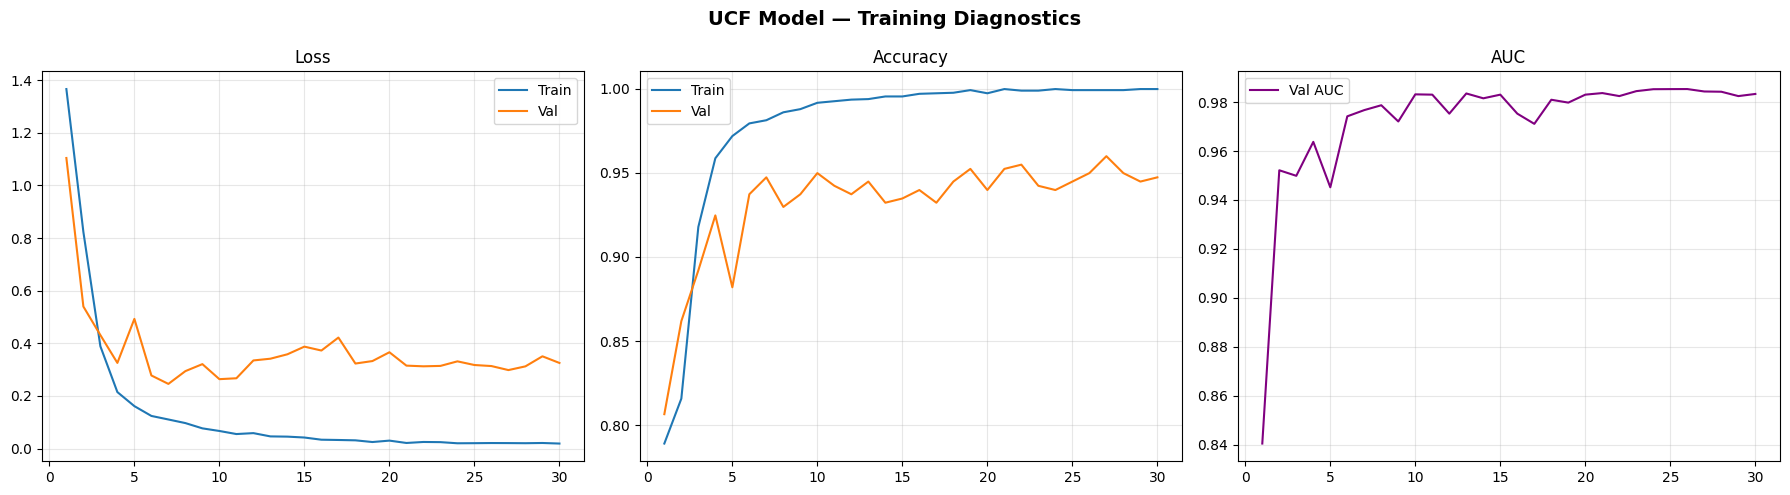

In [12]:
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('UCF Model — Training Diagnostics', fontsize=14, fontweight='bold')

axes[0].plot(ep, history['train_loss'], label='Train'); axes[0].plot(ep, history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train'); axes[1].plot(ep, history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['val_auc'], label='Val AUC', color='purple')
axes[2].set_title('AUC'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ucf_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

TEST RESULTS — UCF
  Accuracy : 96.24% | AUC : 0.9795 | EER : 7.25%


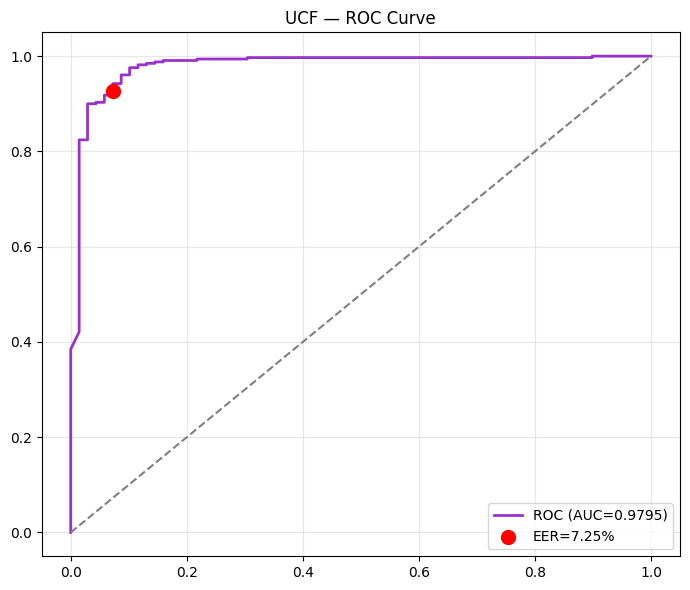

In [13]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'ucf_best.pth')))
_, te_acc, te_auc, probs, labels, fpr, tpr = eval_epoch(model, test_loader)

eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

print("=" * 50)
print(f"TEST RESULTS — UCF")
print(f"  Accuracy : {te_acc*100:.2f}% | AUC : {te_auc:.4f} | EER : {eer*100:.2f}%")
print("=" * 50)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorchid', lw=2, label=f'ROC (AUC={te_auc:.4f})')
ax.scatter([eer], [1-eer], color='red', s=100, zorder=5, label=f'EER={eer*100:.2f}%')
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_title('UCF — ROC Curve'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ucf_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

In [14]:
manip_names = ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures']
manip_results = {}

for m_idx, m_name in enumerate(manip_names):
    subset = [(p, lb, lm) for p, lb, lm in test_s if lb == 0 or lm == m_idx]
    if len(subset) < 10: continue
    loader_m = DataLoader(FFDataset(subset, val_tf), BATCH_SIZE, shuffle=False, num_workers=2)
    _, acc_m, auc_m, pm, lm_arr, fpr_m, tpr_m = eval_epoch(model, loader_m)
    eer_m = brentq(lambda x: 1. - x - interp1d(fpr_m, tpr_m)(x), 0., 1.)
    manip_results[m_name] = {'acc': acc_m, 'auc': auc_m, 'eer': eer_m}
    print(f"  {m_name:18s} → Acc: {acc_m*100:.2f}% | AUC: {auc_m:.4f} | EER: {eer_m*100:.2f}%")

  Deepfakes          → Acc: 92.41% | AUC: 0.9777 | EER: 7.89%
  Face2Face          → Acc: 93.29% | AUC: 0.9841 | EER: 7.25%
  FaceSwap           → Acc: 93.98% | AUC: 0.9881 | EER: 5.15%
  NeuralTextures     → Acc: 92.47% | AUC: 0.9657 | EER: 7.79%


In [15]:
result_lines = [
    "Model: UCF (ICCV 2023)", f"Dataset: FF++ C23", f"Accuracy: {te_acc*100:.2f}%", f"AUC: {te_auc:.4f}", f"EER: {eer*100:.2f}%", "", "Per-Manipulation Results:",
]
for name, r in manip_results.items():
    result_lines.append(f"  {name}: Acc={r['acc']*100:.2f}% AUC={r['auc']:.4f} EER={r['eer']*100:.2f}%")

with open(os.path.join(OUTPUT_DIR, 'ucf_results.txt'), 'w') as f:
    f.write('\n'.join(result_lines))

print("✅ Lưu kết quả xong!")

✅ Lưu kết quả xong!
